## Loading/importing the required libraries

In [1]:
# ! pip install pandas

In [49]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal, chi2_contingency
import seaborn as sns

pd.set_option('display.max_columns', None)

# Step2: Loading the features and the target datasets

In [3]:
#Loading the features
features =pd.read_csv("../data/raw/features.csv")

#Loading the labels
labels =pd.read_csv("../data/raw/labels.csv")

In [4]:
#print the top 5 rows
print("Features: ", display(features.head()))
print("Labels: ", display(labels.head()))

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


Features:  None


,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


Labels:  None


## Step 3: Pre-Cleaning EDA
 - we create a function.

In [5]:
def basic_checks(df):
    print("Dataset shape: ",df.shape)
    print("Duplicated rows: ", df.duplicated().sum())
    print("Missing values: \n",df.isnull().sum())
    print("Basic info: ", df.info())
    print("\nSummary statistics(Numerical): ", display(df.describe().T)) # bkoz we are dataframe we use the display method
    print("\n Summary statistics(Categorical)", display(df.describe(include=['str', 'object']).T))

In [6]:
basic_checks(features)

Dataset shape:  (59400, 40)
Duplicated rows:  0
Missing values: 
 id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
paym

,count,mean,std,min,25%,50%,75%,max
id,59400.0,37115.131768,21453.128371,0.00000,18519.750000,37061.500000,55656.500000,7.424700e+04
amount_tsh,59400.0,317.650385,2997.574558,0.00000,0.000000,0.000000,20.000000,3.500000e+05
gps_height,59400.0,668.297239,693.116350,-90.00000,0.000000,369.000000,1319.250000,2.770000e+03
longitude,59400.0,34.077427,6.567432,0.00000,33.090347,34.908743,37.178387,4.034519e+01
latitude,59400.0,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-2.000000e-08
num_private,59400.0,0.474141,12.236230,0.00000,0.000000,0.000000,0.000000,1.776000e+03
region_code,59400.0,15.297003,17.587406,1.00000,5.000000,12.000000,17.000000,9.900000e+01
district_code,59400.0,5.629747,9.633649,0.00000,2.000000,3.000000,5.000000,8.000000e+01
population,59400.0,179.909983,471.482176,0.00000,0.000000,25.000000,215.000000,3.050000e+04
construction_year,59400.0,1300.652475,951.620547,0.00000,0.000000,1986.000000,2004.000000,2.013000e+03



Summary statistics(Numerical):  None


,count,unique,top,freq
date_recorded,59400,356,2011-03-15,572
funder,55763,1896,Government Of Tanzania,9084
installer,55745,2145,DWE,17402
wpt_name,59398,37399,none,3563
basin,59400,9,Lake Victoria,10248
subvillage,59029,19287,Madukani,508
region,59400,21,Iringa,5294
lga,59400,125,Njombe,2503
ward,59400,2092,Igosi,307
public_meeting,56066,2,True,51011



 Summary statistics(Categorical) None


In [7]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [8]:
# Convert the date recorded and construction year columns into datetime formats.

features['date_recorded'] = pd.to_datetime(features['date_recorded'], errors ='coerce')
features['construction_year'] = pd.to_datetime(features['construction_year'], errors ='coerce')


In [9]:
features.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1970-01-01 00:00:00.000001999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,1970-01-01 00:00:00.000002010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,1970-01-01 00:00:00.000002009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1970-01-01 00:00:00.000001986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,1970-01-01 00:00:00.000000000,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


In [10]:
features.dtypes

id                                int64
amount_tsh                      float64
date_recorded            datetime64[us]
funder                              str
gps_height                        int64
installer                           str
longitude                       float64
latitude                        float64
wpt_name                            str
num_private                       int64
basin                               str
subvillage                          str
region                              str
region_code                       int64
district_code                     int64
lga                                 str
ward                                str
population                        int64
public_meeting                   object
recorded_by                         str
scheme_management                   str
scheme_name                         str
permit                           object
construction_year        datetime64[ns]
extraction_type                     str


In [11]:
features.shape

(59400, 40)

In [12]:
labels.shape

(59400, 2)

In [13]:
# Merge the target and the features
data_df = pd.merge(features, labels, on='id', how ='inner')

In [14]:
data_df.head(5)

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1970-01-01 00:00:00.000001999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,1970-01-01 00:00:00.000002010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,1970-01-01 00:00:00.000002009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1970-01-01 00:00:00.000001986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,1970-01-01 00:00:00.000000000,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11176\1523843198.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_df, x='status_group', palette='colorblind')


<function matplotlib.pyplot.show(close=None, block=None)>

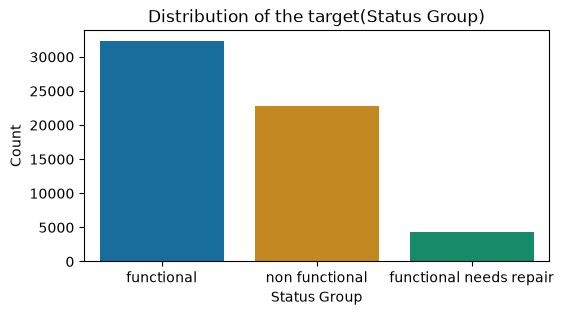

In [15]:
# Check the distribution of the target classes(value counts,)

(data_df['status_group'].value_counts())

# Alternatively
# Plot the distribution
plt.figure(figsize=(6, 3))
sns.countplot(data=data_df, x='status_group', palette='colorblind')
plt.title("Distribution of the target(Status Group)")
plt.xlabel("Status Group")
plt.ylabel("Count")
plt.show


## Check for different categories in the categorical features

In [16]:
categorical_cols = data_df.select_dtypes(include=['str', 'object']).columns.tolist()

print(categorical_cols)

# checking for unique entries
for col in categorical_cols:
    print('-'*40, col.upper(), '-'*40)
    print(data_df[col].unique())

['funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']
---------------------------------------- FUNDER ----------------------------------------
<StringArray>
[               'Roman',              'Grumeti',         'Lottery Club',
               'Unicef',          'Action In A',  'Mkinga Distric Coun',
                 'Dwsp',                'Rwssp',             'Wateraid',
          'Isingiro Ho',
 ...
                 'Tove',           'Nerthlands',       'Nazalet Church',
 'Scharnhorstgymnasium',       'Wanginyi Water',                 'Cida',
  'Dwe/anglican Church',                 'Di

In [17]:
data_df['installer'].nunique()

2145

In [18]:
data_df.columns

Index(['id', 'amount_tsh', 'date_recorded', 'funder', 'gps_height',
       'installer', 'longitude', 'latitude', 'wpt_name', 'num_private',
       'basin', 'subvillage', 'region', 'region_code', 'district_code', 'lga',
       'ward', 'population', 'public_meeting', 'recorded_by',
       'scheme_management', 'scheme_name', 'permit', 'construction_year',
       'extraction_type', 'extraction_type_group', 'extraction_type_class',
       'management', 'management_group', 'payment', 'payment_type',
       'water_quality', 'quality_group', 'quantity', 'quantity_group',
       'source', 'source_type', 'source_class', 'waterpoint_type',
       'waterpoint_type_group', 'status_group'],
      dtype='str')

In [19]:
# Listing the final columns

columns_to_keep = ['amount_tsh', 'date_recorded', 'gps_height', 'basin', 'region',
                   'population', 'scheme_management', 'permit', 'construction_year',
                   'extraction_type_class', 'payment_type', 'quality_group', 'quantity_group',
                   'source_type', 'waterpoint_type_group', 'status_group']

filtered_df = data_df[columns_to_keep]

filtered_df.shape


(59400, 16)

In [20]:
# Create a new 'month' column from date recorded column

filtered_df['month_recorded'] = filtered_df['date_recorded'].dt.month

In [21]:
filtered_df.head(5)

,amount_tsh,date_recorded,gps_height,basin,region,population,scheme_management,permit,construction_year,extraction_type_class,payment_type,quality_group,quantity_group,source_type,waterpoint_type_group,status_group,month_recorded
0,6000.0,2011-03-14,1390,Lake Nyasa,Iringa,109,VWC,False,1970-01-01 00:00:00.000001999,gravity,annually,good,enough,spring,communal standpipe,functional,3
1,0.0,2013-03-06,1399,Lake Victoria,Mara,280,Other,True,1970-01-01 00:00:00.000002010,gravity,never pay,good,insufficient,rainwater harvesting,communal standpipe,functional,3
2,25.0,2013-02-25,686,Pangani,Manyara,250,VWC,True,1970-01-01 00:00:00.000002009,gravity,per bucket,good,enough,dam,communal standpipe,functional,2
3,0.0,2013-01-28,263,Ruvuma / Southern Coast,Mtwara,58,VWC,True,1970-01-01 00:00:00.000001986,submersible,never pay,good,dry,borehole,communal standpipe,non functional,1
4,0.0,2011-07-13,0,Lake Victoria,Kagera,0,NaN,True,1970-01-01 00:00:00.000000000,gravity,never pay,good,seasonal,rainwater harvesting,communal standpipe,functional,7


In [22]:
# create a new column age
filtered_df['age'] = filtered_df['date_recorded'].dt.year - filtered_df['construction_year'].dt.year

In [23]:
filtered_df.head()

,amount_tsh,date_recorded,gps_height,basin,region,population,scheme_management,permit,construction_year,extraction_type_class,payment_type,quality_group,quantity_group,source_type,waterpoint_type_group,status_group,month_recorded,age
0,6000.0,2011-03-14,1390,Lake Nyasa,Iringa,109,VWC,False,1970-01-01 00:00:00.000001999,gravity,annually,good,enough,spring,communal standpipe,functional,3,41
1,0.0,2013-03-06,1399,Lake Victoria,Mara,280,Other,True,1970-01-01 00:00:00.000002010,gravity,never pay,good,insufficient,rainwater harvesting,communal standpipe,functional,3,43
2,25.0,2013-02-25,686,Pangani,Manyara,250,VWC,True,1970-01-01 00:00:00.000002009,gravity,per bucket,good,enough,dam,communal standpipe,functional,2,43
3,0.0,2013-01-28,263,Ruvuma / Southern Coast,Mtwara,58,VWC,True,1970-01-01 00:00:00.000001986,submersible,never pay,good,dry,borehole,communal standpipe,non functional,1,43
4,0.0,2011-07-13,0,Lake Victoria,Kagera,0,NaN,True,1970-01-01 00:00:00.000000000,gravity,never pay,good,seasonal,rainwater harvesting,communal standpipe,functional,7,41


In [24]:
# check for the remaining nulls.

nulls = (filtered_df.isnull().sum()/len(filtered_df)*100)

nulls

amount_tsh               0.000000
date_recorded            0.000000
gps_height               0.000000
basin                    0.000000
region                   0.000000
population               0.000000
scheme_management        6.528620
permit                   5.144781
construction_year        0.000000
extraction_type_class    0.000000
payment_type             0.000000
quality_group            0.000000
quantity_group           0.000000
source_type              0.000000
waterpoint_type_group    0.000000
status_group             0.000000
month_recorded           0.000000
age                      0.000000
dtype: float64

## Thresholds to deal with missing values
- 35% or above missing values: Drop the whole column.
- 34% or below: 
    - (Numerical) Fill using either mean or median
    - (Categorical) Fill using most frequent which is the mode.
- 0 to 5%: drop the rows with the missing values. fill the nulls.

In [25]:
# Drop the rows with the missing values

filtered_df = filtered_df.dropna(subset=['scheme_management', 'permit'])

In [26]:
# check again for the remaining nulls.

nulls = (filtered_df.isnull().sum()/len(filtered_df)*100)

nulls

amount_tsh               0.0
date_recorded            0.0
gps_height               0.0
basin                    0.0
region                   0.0
population               0.0
scheme_management        0.0
permit                   0.0
construction_year        0.0
extraction_type_class    0.0
payment_type             0.0
quality_group            0.0
quantity_group           0.0
source_type              0.0
waterpoint_type_group    0.0
status_group             0.0
month_recorded           0.0
age                      0.0
dtype: float64

## Recheck the categorical entries and the categorical columns


In [27]:
## Get the categorical columns
categorical_cols = filtered_df.select_dtypes(include=['str', 'object']).columns.tolist()

print(categorical_cols)


# checking for unique entries
for col in categorical_cols:
    print('-'*40, col.upper(), '-'*40)
    print(filtered_df[col].unique())


['basin', 'region', 'scheme_management', 'permit', 'extraction_type_class', 'payment_type', 'quality_group', 'quantity_group', 'source_type', 'waterpoint_type_group', 'status_group']
---------------------------------------- BASIN ----------------------------------------
<StringArray>
[             'Lake Nyasa',           'Lake Victoria',
                 'Pangani', 'Ruvuma / Southern Coast',
                'Internal',         'Lake Tanganyika',
             'Wami / Ruvu',                  'Rufiji',
              'Lake Rukwa']
Length: 9, dtype: str
---------------------------------------- REGION ----------------------------------------
<StringArray>
[       'Iringa',          'Mara',       'Manyara',        'Mtwara',
         'Tanga',     'Shinyanga',        'Tabora',         'Pwani',
        'Ruvuma',   'Kilimanjaro',         'Rukwa',        'Kigoma',
         'Lindi',        'Dodoma',         'Mbeya',        'Arusha',
        'Mwanza',        'Kagera',       'Singida',      'Morogoro

In [28]:

# Remove space before and after the forward slashes in the basin classes i.e 'Ruvuma / Southern Coast' to 'Ruvuma/Southern Coast'

filtered_df['basin'] = filtered_df['basin'].replace({'Wami / Ruvu': 'Wami/Ruvu', 'Ruvuma / Southern Coast': 'Ruvuma/Southern Coast'})


In [29]:
## Get the categorical columns
categorical_cols = filtered_df.select_dtypes(include=['str', 'object']).columns.tolist()

print(categorical_cols)


# checking for unique entries
for col in categorical_cols:
    print('-'*40, col.upper(), '-'*40)
    print(filtered_df[col].unique())

['basin', 'region', 'scheme_management', 'permit', 'extraction_type_class', 'payment_type', 'quality_group', 'quantity_group', 'source_type', 'waterpoint_type_group', 'status_group']
---------------------------------------- BASIN ----------------------------------------
<StringArray>
[           'Lake Nyasa',         'Lake Victoria',               'Pangani',
 'Ruvuma/Southern Coast',              'Internal',       'Lake Tanganyika',
             'Wami/Ruvu',                'Rufiji',            'Lake Rukwa']
Length: 9, dtype: str
---------------------------------------- REGION ----------------------------------------
<StringArray>
[       'Iringa',          'Mara',       'Manyara',        'Mtwara',
         'Tanga',     'Shinyanga',        'Tabora',         'Pwani',
        'Ruvuma',   'Kilimanjaro',         'Rukwa',        'Kigoma',
         'Lindi',        'Dodoma',         'Mbeya',        'Arusha',
        'Mwanza',        'Kagera',       'Singida',      'Morogoro',
 'Dar es Salaam']

In [30]:
## Save the cleaned dataset
filtered_df.to_csv('../data/processed/cleaned_data.csv', index =0)

## 21st July 2026
### Post-Cleaning EDA
__Types of analysis visualizations__
- Univariate analysis: Single variable/column analysis
- Bivariate analysis: Two variable. 
- Multivariate analysis: Analysis for more than two variables/columns.(3 or more columns)

#### Univariate analysis
- Distribution of the target variable classes


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11176\1404960557.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(filtered_df, x='status_group', palette='colorblind')


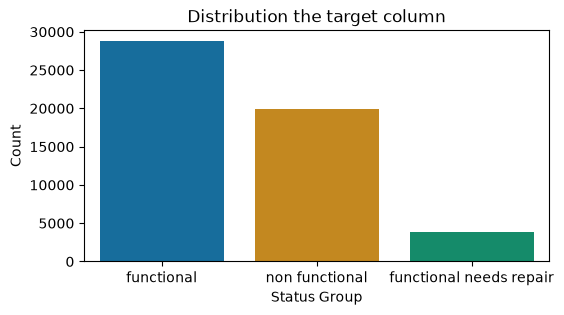

In [31]:
# Distribution of the target variable classes (categorical column).   
plt.figure(figsize=(6, 3))
sns.countplot(filtered_df, x='status_group', palette='colorblind')
plt.title("Distribution the target column")
plt.xlabel("Status Group")
plt.ylabel("Count")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11176\4268989235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(filtered_df, x='waterpoint_type_group', palette='colorblind')


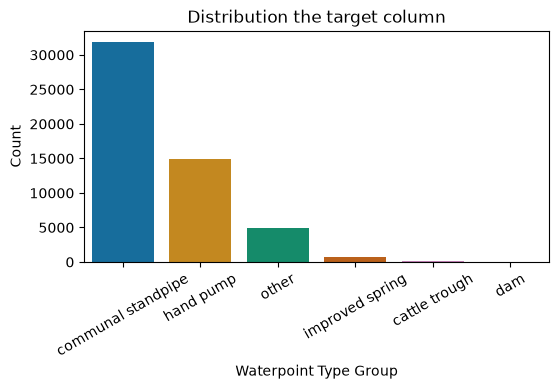

In [32]:
# Distribution of the target variable classes(categorical).   
plt.figure(figsize=(6, 3))
sns.countplot(filtered_df, x='waterpoint_type_group', palette='colorblind')
plt.title("Distribution the target column")
plt.xlabel("Waterpoint Type Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

__numerical column__
- Distribution reveals how data points span across a specific range.
- 

__Normal Distribution__

__Other distribution__



<function matplotlib.pyplot.show(close=None, block=None)>

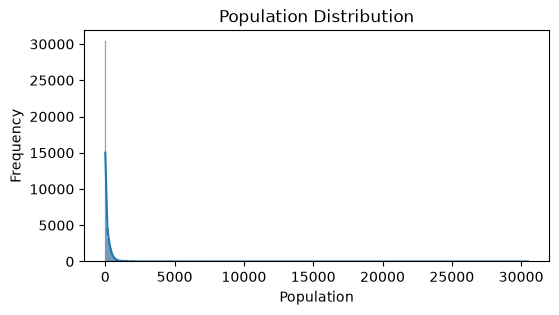

In [33]:
# Distribution of the population(numerical column).  
plt.figure(figsize=(6, 3))
sns.histplot(filtered_df, x='population', kde=True)
plt.title("Population Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

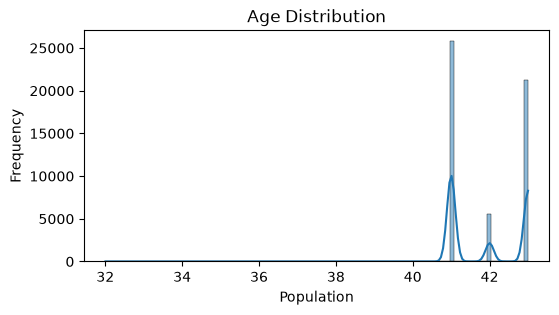

In [34]:
# Plot for the age column
plt.figure(figsize=(6, 3))
sns.histplot(filtered_df, x='age', kde=True)
plt.title("Age Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show

### Bivariate Analysis
__Categorical vs Categorical__


<function matplotlib.pyplot.show(close=None, block=None)>

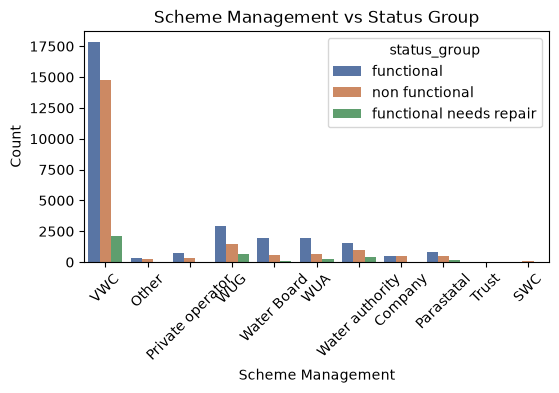

In [35]:
# scheme management vs status group
plt.figure(figsize=(6, 3))
sns.countplot(filtered_df, x='scheme_management', hue='status_group', palette='deep')
plt.title("Scheme Management vs Status Group")
plt.xlabel("Scheme Management")
plt.ylabel("Count")
plt.xticks(rotation =45)
plt.show

__Numerical vs categorical_cols__

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11176\1361335449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(filtered_df, x='status_group', y='gps_height', palette='deep', estimator='mean')


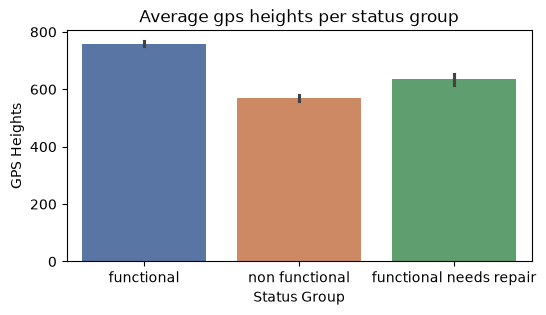

In [36]:
# Plot average GPS Heights in each Group Status
plt.figure(figsize=(6, 3))
sns.barplot(filtered_df, x='status_group', y='gps_height', palette='deep', estimator='mean')
plt.title("Average gps heights per status group")
plt.xlabel("Status Group")
plt.ylabel("GPS Heights")
plt.show()

__Numerical vs Numerical__


In [37]:
filtered_df.columns

Index(['amount_tsh', 'date_recorded', 'gps_height', 'basin', 'region',
       'population', 'scheme_management', 'permit', 'construction_year',
       'extraction_type_class', 'payment_type', 'quality_group',
       'quantity_group', 'source_type', 'waterpoint_type_group',
       'status_group', 'month_recorded', 'age'],
      dtype='str')

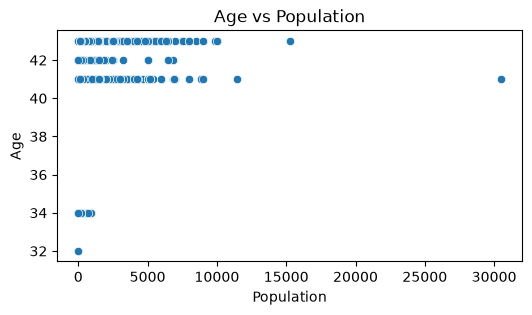

In [38]:
# Age vs population
plt.figure(figsize=(6, 3))

sns.scatterplot(filtered_df, x='population', y = 'age')
plt.title("Age vs Population")
plt.xlabel("Population")
plt.ylabel("Age")
plt.show()

__Multivariate Analysis__

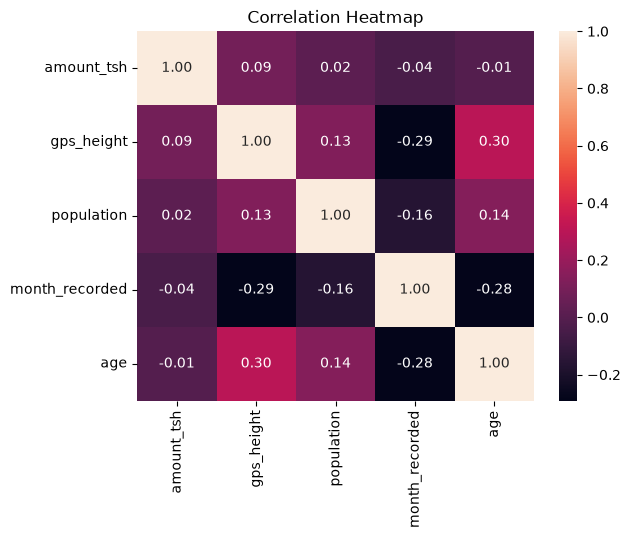

In [39]:
# Plot the correlation Heatmap
# Correlation Heatmap.  
numerical_cols = filtered_df.select_dtypes(include=['int', 'float']).columns.tolist()
  
correlation = filtered_df[numerical_cols].corr()

sns.heatmap(correlation, annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

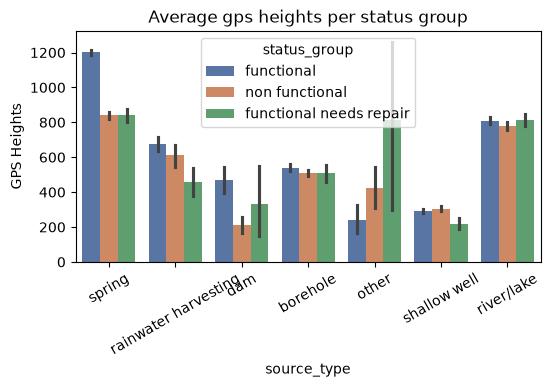

In [40]:
# Plot average GPS Heights in each Source Type per Group Status
plt.figure(figsize=(6, 3))
sns.barplot(filtered_df, x='source_type', y='gps_height', hue= 'status_group', palette='deep', estimator='mean')
plt.title("Average gps heights per status group")
plt.xlabel("source_type")
plt.ylabel("GPS Heights")
plt.xticks(rotation =30)
plt.show()

### Hypothesis Testing
__Hypothesis testing:__ is a statistical method used to determine whether there's enough evidence in data to support a claim about a relationship between variables.
- It helps us in:
    - Feature selection.
    - EDA(To evaluate and see if data makes statistical sense).
    - understanding varible relationships.
    - Reduction of irrelevant features.

#### Core ideas of hypothesis testing.
__Null Hypothesis(H<sub>0</sub>):__ This is the default assumption that there's no effect, no relationship, no difference btwn groups.
_Example_ Gender and loan approval (Null hypothesis will be gender and loan approval are independent meaning the feature gender doesn't affect the target which is loan approval and the observed difference is by normal chance).

__Alternative Hypothesis(H<sub>1</sub>):__ This is what we are trying to prove.
_Example_ Gender and Loan approval are associated(Meaning that there's predictive information from the gender feature).

__Defition of terms__
- Alpha/Level of significance($\alpha$): it is the 'cutoff' for statistical significance. Mostly used alpha is 0.5/5%, 0.01/1%.
- p-value: The probability of observing results atleast as extreme as the current data assuming the null hypothesis is true.

_Evaluation or judgement_
|Condition  |Decision            |
|-----------|--------------------|
|p <= alpha | reject H0          |
|p > alpha  | Fail to reject H0  |

- Type I Error(False Positive): when we reject the null hypothesis that is actually true.
- Type II Error(False Negative): When we fail to reject the null hypothesis.


_How do you choose the best hypothesis_
| Features type| Target Variable      |              Recommended test         |
|--------------|----------------------|---------------------------------------|
|Numerical     |Numerical             | Correlation/Regression                |
|Numerical     |Categorical(Binary)   | independent t-test/Mann-Whitney U test|
|Numerical     |Categorical(Multiclass)|One-Way ANOVA/Kruskal-Wallis test     |
|Categorical   | Categorucal          | CHI-Square test of independence       |

#### Parametric tests.
- Parametric tests assume an underlying distribution (normal distribution)
- Examples :
    - Independent t-test
    - One-Way ANOVA
    - z-tests.

_Assumptions of parametric tests_
- Normality: The population from which the data is sampled must follow an approximately normal distribution.(bell curve).
- Homogenity of variance: The variance/spread of the data should be roughly equal across all groups being compared. eg our three groups of the target.
- Independence of observations: each category/class must be independent.
- Continous data.(numerical)

n/b=> discrete data (numerical data type is more of another categorical.) is a representation of say like a unique identifier. eg addmmision number and doesn't have a decimal point. or monday - 1, tuesday -2, wednesday -3, Thursday -4. 

#### Non-Parametric
- Non-Parametric tests make no strict assumption about the population and are often called "distribution-free" tests.
- We use it when the assumptions are conducted.
- 

# Numerical vs Categorical column

In [41]:

print(numerical_cols)

# Relationship between population and status_group

h0 = "There is no difference in the distribution of population amongst status groups"
h1 = "Atleast one status group population differs"

alpha = 0.05 # 5%

groups = [group['population'].values for name, group in filtered_df.groupby('status_group')]

# Test statistics
stat, p = kruskal(*groups) # we use * for it to accomande any no of classes

print("Test statistics", stat)
print("P-Value", p)

if p <= alpha:
    print(f"Reject the null hypothesis '{h0}'") # there is an actual relationship btwn the two columns.
else:
    print(f"Fail to reject the null hypothesis '{h0}'") # there is no relationship btwn the two. 

['amount_tsh', 'gps_height', 'population', 'month_recorded', 'age']
Test statistics 37.71608522216001
P-Value 6.457377178733762e-09
Reject the null hypothesis 'There is no difference in the distribution of population amongst status groups'


In [42]:
groups

[array([109, 280, 250, ...,   0,   0, 150], shape=(28733,)),
 array([350, 140, 180, ...,   1, 500,  35], shape=(3796,)),
 array([ 58,   0,   0, ..., 210,   0,  89], shape=(19978,))]

In [43]:
#example
car_brands = {'USA': ['CHEVROLET', 'FORD', 'GMC'],
              'Japan': ['Toyato', 'Honda', 'Nissan']}
for key, value in car_brands.items():
    print(value)

['CHEVROLET', 'FORD', 'GMC']
['Toyato', 'Honda', 'Nissan']


In [44]:
for col in numerical_cols:
    print('-'*40, col.upper(), '-'*40)
    h0 = f"There is no relationship in the distribution of {col} amongst status groups"
    h1 = f"Atleast one status group {col} differs"

    alpha = 0.05 # 5%

    groups = [group[col].values for name, group in filtered_df.groupby('status_group')]

    stat, p = kruskal(*groups)    

    print("Test statistic", stat)
    print("P-Value", p)

    if p <= alpha:
        print(f"Reject the null hypothesis '{h0}'") # There's an actual relationship between the two columns
    else:
        print(f"Fail to reject the null hypothesis '{h0}'") # There's no relationship

---------------------------------------- AMOUNT_TSH ----------------------------------------
Test statistic 2647.7828247531875
P-Value 0.0
Reject the null hypothesis 'There is no relationship in the distribution of amount_tsh amongst status groups'
---------------------------------------- GPS_HEIGHT ----------------------------------------
Test statistic 699.7526557716039
P-Value 1.1236768940004177e-152
Reject the null hypothesis 'There is no relationship in the distribution of gps_height amongst status groups'
---------------------------------------- POPULATION ----------------------------------------
Test statistic 37.71608522216001
P-Value 6.457377178733762e-09
Reject the null hypothesis 'There is no relationship in the distribution of population amongst status groups'
---------------------------------------- MONTH_RECORDED ----------------------------------------
Test statistic 228.99606076887736
P-Value 1.8799106803547708e-50
Reject the null hypothesis 'There is no relationship in

#### 22nd July 2026

_Categorical vs Categorical(CHi-Square test of independence)_     
Chi-Square test of independence is a statistical test used to determine if there's a significant association/relationship between two categorical variables in the same dataset.     

It helps you decide whether variables are related or no.         

_Formula_    
$\chi ^{2}=\sum \frac{(O-E)^{2}}{E}$      

Where:    
O = Observed values.   
E = Expected values if there was no association between the values.

In [46]:
filtered_df.columns

Index(['amount_tsh', 'date_recorded', 'gps_height', 'basin', 'region',
       'population', 'scheme_management', 'permit', 'construction_year',
       'extraction_type_class', 'payment_type', 'quality_group',
       'quantity_group', 'source_type', 'waterpoint_type_group',
       'status_group', 'month_recorded', 'age'],
      dtype='str')

In [54]:
#Permit vs Status Group
h0 = "There's no relationship between permit and status group(Both are independent)"
h1 = "There is a relationship between permit and status group(the two are dependent variables)"

alpha = 0.05 # 5%

observed = pd.crosstab(filtered_df["permit"], filtered_df["status_group"])

# observed

chi2, p, dof, expected =  chi2_contingency(observed) # degrees of freedom

print("P-Value: ",p)
print("expected values: \n", pd.DataFrame(expected))

if p<= alpha:
    print(f"Reject the null hypothesis '{h0}'")
elif p> alpha:
    print(f"Fail to reject the null hypothesis '{h0}'")

P-Value:  1.4726377912412108e-20
expected values: 
               0            1             2
0   9313.723123  1230.462986   6475.813891
1  19419.276877  2565.537014  13502.186109
Reject the null hypothesis 'There's no relationship between permit and status group(Both are independent)'


In [53]:
observed

status_group,functional,functional needs repair,non functional
permit,,,
False,8804,1301,6915
True,19929,2495,13063


In [ ]:
#Permit vs Status Group
h0 = "There's no relationship between permit and status group(Both are independent)"
h1 = "There is a relationship between permit and status group(the two are dependent variables)"

alpha = 0.05 # 5%

observed = pd.crosstab(filtered_df["extraction_type_class"], filtered_df["status_group"])

# observed

chi2, p, dof, expected =  chi2_contingency(observed) # degrees of freedom

print("P-Value: ",p)
print("expected values: \n", pd.DataFrame(expected))

In [64]:
# categorical_columns

# categorical_columns.remove('status_group')

for column in categorical_cols:
    print('-'*40, column.upper(),'-'*40)

    h0 = f"There's no relationship between {column} and status group(Both status group and {column} are independent)" 
    h1 = f"There is a relationship between {column} and status group(Both status group and {column} are depend)"  

    alpha = 0.05 # 5%

    observed = pd.crosstab(filtered_df[column], filtered_df["status_group"])

    chi2, p, dof, expected = chi2_contingency(observed)
    
    print("P-Value: ",p)
    # print("Expected values: \n", pd.DataFrame(expected))


    if p <= alpha:
        print(f"Reject the null hypothesis '{h0}'")
    elif p > alpha:
        print(f"Fail to reject the null hypothesis '{h0}'")


---------------------------------------- BASIN ----------------------------------------
P-Value:  0.0
Reject the null hypothesis 'There's no relationship between basin and status group(Both status group and basin are independent)'
---------------------------------------- REGION ----------------------------------------
P-Value:  0.0
Reject the null hypothesis 'There's no relationship between region and status group(Both status group and region are independent)'
---------------------------------------- SCHEME_MANAGEMENT ----------------------------------------
P-Value:  0.0
Reject the null hypothesis 'There's no relationship between scheme_management and status group(Both status group and scheme_management are independent)'
---------------------------------------- PERMIT ----------------------------------------
P-Value:  1.4726377912412108e-20
Reject the null hypothesis 'There's no relationship between permit and status group(Both status group and permit are independent)'
---------------

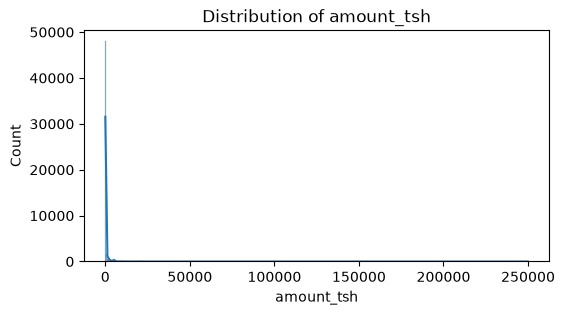

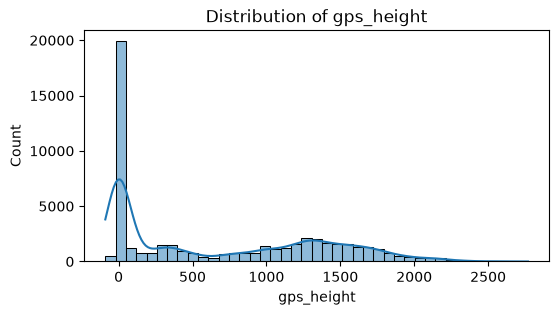

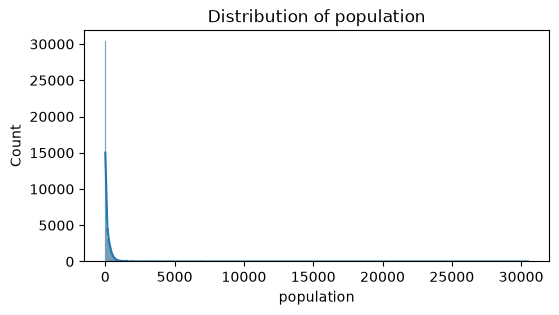

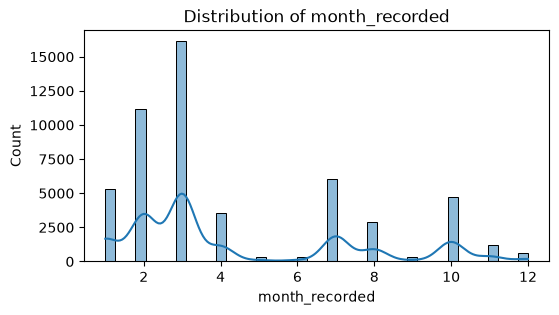

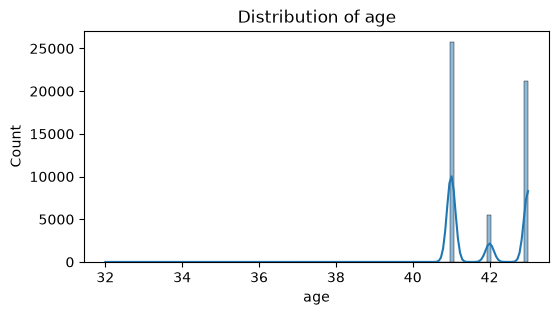

In [57]:
numerical_cols

for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(filtered_df, x=col, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col}")
    plt.show()

#### DISCLAIMER !! One-Way ANOVA test below is for demostration purposes only since the numerical columns are not normally distributted.


In [58]:
from scipy.stats import f_oneway

In [59]:
# Population vs Status Group
h0 = "The mean/average population is equal across all status groups"
h1 = "The mean/average population differs in atleast one status group"

alpha = 0.05

groups = [group['population'].values for name, group in filtered_df.groupby('status_group')]

stat, p = f_oneway(*groups)  

print("P-Value: ", p)

if p <= alpha:
    print(f"Reject the null hypothesis '{h0}'")
else:
    print(f"Fail to reject the null hypothesis '{h0}'") 

P-Value:  0.04433200709583346
Reject the null hypothesis 'The mean/average population is equal across all status groups'


In [45]:
numbers = [1, 2, 3, 4, 50]
mean = sum(numbers)/len(numbers)
print(mean)

median = np.median(numbers)
print(median)

12.0
3.0
